# 🎯 Do Favourites Really Win?

This notebook explores one of the most common beliefs in horse racing:

### 📣 What people say about favourites in racing:

> “Favourites win more often, but the odds are too short to be profitable.”  
> — [FlatStats.co.uk](https://www.flatstats.co.uk/horseracing/index.php?cmd=article&id=102)

> “While the favourite has a higher chance of winning, it doesn't mean you will make a profit betting on them.”  
> — [GrandNational.Fans](https://www.grandnational.fans/news/how-often-do-favourites-win/)

> “The favourite–longshot bias... is the empirical finding that bettors tend to overvalue longshots and undervalue favourites.”  
> — [Wikipedia](https://en.wikipedia.org/wiki/Favourite–longshot_bias)

These are widely accepted ideas in both betting communities and academic literature.  
In this notebook, we’ll test whether they hold true — using real race data!

---

## 🧪 What We'll Do

We'll examine the relationship between **implied probability** and **actual outcomes**:

- Do favourites win as often as their odds suggest?
- Are longshots consistently overbet?
- Is the market well-calibrated overall?
- Can we build a simple baseline model from this?

Let’s begin by loading our cleaned dataset.

In [18]:
# 📦 Import libraries
import pandas as pd

# 📂 Load cleaned data
YEAR = 2019
horses = pd.read_csv(f"../data/processed/horses_{YEAR}_clean.csv")
races = pd.read_csv(f"../data/processed/races_{YEAR}_clean.csv")


# ✅ Confirm successful load
print("✅ Data loaded")
print(f"🐎 Horses: {horses.shape}")
print(f"🏁 Races: {races.shape}")

# 🔍 Preview
horses[['horseName', 'implied_prob', 'isFav', 'position', 'did_finish']].sample(5)

✅ Data loaded
🐎 Horses: (171849, 28)
🏁 Races: (17307, 18)


,horseName,implied_prob,isFav,position,did_finish
48685,Groundworker,0.076923,0,3.0,1
118283,Pravalaguna,0.066667,0,5.0,1
70236,Cesar Et Rosalie,0.421053,1,NaN,0
66984,Only Orsenfoolsies,0.029412,0,1.0,1
71121,McKinzie,0.377358,1,2.0,1


## 🎯 Goal: Are Odds Well-Calibrated?

In this section, we’ll explore how well the **implied probabilities** from bookmaker odds match up to **actual outcomes**.

Specifically, we’re asking:

- Do horses with a 30% implied chance actually win 30% of the time?
- Do favourites win as often as their odds suggest?
- Is the market well-calibrated — or are there patterns of bias?

By comparing implied probabilities to real win rates, we can test for:
- ✅ Market accuracy
- ⚠️ Favourite–longshot bias
- 🎯 Potential opportunities for value betting

We'll use our cleaned 2019 horse-level dataset to run this calibration check.


### 📊 Step 1: Is the Market Well-Calibrated?

In betting markets, **implied probability** (derived from odds) is meant to reflect a horse’s true chance of winning. But does it?

In this step, we’ll test how well the market predicts reality — a concept known as **calibration**.

#### 🧪 What We'll Do:
- 📦 Group horses into bins based on their implied probability (e.g. 0.00–0.05, 0.05–0.10, etc.)
- 📈 Calculate the actual win rate within each bin
- 🪞 Compare **predicted** (implied) vs. **actual** win rates

#### 🎯 Why It Matters:
- If horses with a 30% implied chance win about 30% of the time, the market is **well-calibrated**
- If not, we might detect:
  - Overvalued favourites (⚠️ *Favourite–Longshot Bias*)
  - Undervalued outsiders (🎯 *potential for value betting*)

Let’s find out what the data says.



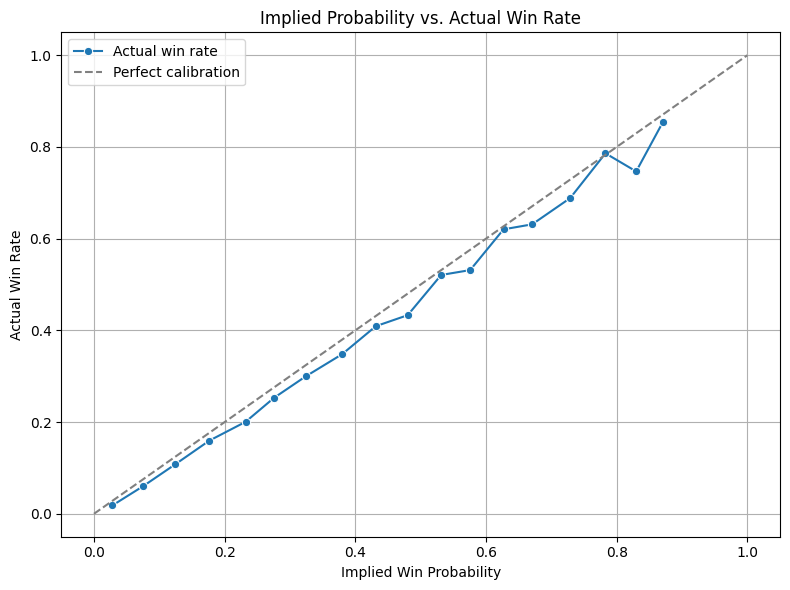

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Start from cleaned horses data
df = horses.copy()

# Create is_winner flag if not already present
if 'is_winner' not in df.columns:
    df['is_winner'] = (df['position'] == 1).astype(int)

# Keep only horses that finished
df = df[df['did_finish'] == 1].copy()

# Bin implied probabilities into 20 equal-width bins (0.0 to 1.0)
df['prob_bin'] = pd.cut(df['implied_prob'], bins=np.linspace(0, 1, 21))

# Group by bin and compute calibration metrics
calibration = df.groupby('prob_bin').agg(
    mean_implied_prob=('implied_prob', 'mean'),
    actual_win_rate=('is_winner', 'mean'),
    count=('is_winner', 'count')
).reset_index()

# Filter out bins with too few samples (optional threshold)
calibration = calibration[calibration['count'] >= 50]

# Plot calibration curve
plt.figure(figsize=(8, 6))
sns.lineplot(data=calibration, x='mean_implied_prob', y='actual_win_rate', marker='o', label='Actual win rate')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
plt.title('Implied Probability vs. Actual Win Rate')
plt.xlabel('Implied Win Probability')
plt.ylabel('Actual Win Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

### ✅ Step 1 Summary: Market Calibration

Our calibration plot shows how well the betting market’s implied probabilities match actual outcomes:

- 📐 The closer the calibration curve is to the diagonal line, the more accurate the market’s probabilities.
- 🧠 In our case, the market is **remarkably well-calibrated**, especially in the 0.1 to 0.4 probability range.
- ⚠️ Some **favourite-longshot bias** is visible:
  - Horses with very low implied probabilities (longshots) tend to win **less often** than their odds suggest.
  - Strong favourites tend to win **slightly more often** than expected.

This confirms a key principle: **the market is smart — but not perfect**. These patterns hint at where bettors might overpay or underpay for risk.

Next, we’ll explore profitability: is betting on favourites ever worth it?



### 💸 Step 2: Profitability of Betting at SP Odds

In the previous step, we confirmed that the market is reasonably well-calibrated — horses with a 30% implied chance do tend to win about 30% of the time. But that doesn’t tell us whether betting at those odds is profitable.

This step explores **returns** rather than accuracy.

📊 **Key question:**  
If we bet £1 on every horse — grouped by implied probability — do favourites or longshots produce better average returns?

📌 We'll:

- Group runners into 20 implied probability bins (e.g. 0.00–0.05, 0.05–0.10, etc.)
- Calculate the **average return** in each bin (return = 0 for losses, odds - 1 for wins)
- Visualise profit/loss by bin

🧠 This helps us investigate:

- Whether favourites are systematically overbet (and therefore unprofitable)
- Whether longshots are mispriced
- Whether any segments of the market show potential for **value betting**
- The existence (or absence) of the **favourite–longshot bias**


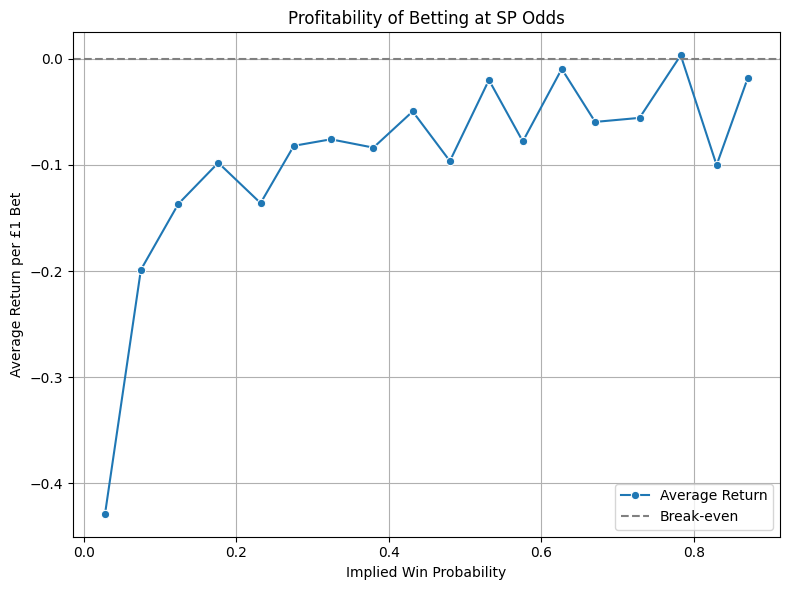

In [26]:
# Recalculate decimal odds from implied probability (odds = 1 / prob)
df['decimal_odds'] = 1 / df['implied_prob']

# Calculate return per £1 bet
df['return'] = np.where(df['is_winner'] == 1, df['decimal_odds'] - 1, -1)

# Bin probabilities
df['prob_bin'] = pd.cut(df['implied_prob'], bins=np.linspace(0, 1, 21))

# Group by bin
returns = df.groupby('prob_bin').agg(
    mean_implied_prob=('implied_prob', 'mean'),
    avg_return=('return', 'mean'),
    count=('return', 'count')
).reset_index()

# Filter low-sample bins
returns = returns[returns['count'] >= 50]

# Plot
plt.figure(figsize=(8, 6))
sns.lineplot(data=returns, x='mean_implied_prob', y='avg_return', marker='o', label='Average Return')
plt.axhline(0, color='grey', linestyle='--', label='Break-even')
plt.title("Profitability of Betting at SP Odds")
plt.xlabel("Implied Win Probability")
plt.ylabel("Average Return per £1 Bet")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 💸 Summary: Profitability of SP Odds

This chart explores the **expected returns from betting £1 on every horse** in different implied probability bands.

**Key insights:**

- 🟥 **Negative Returns Across the Board:** On average, betting at SP odds is **not profitable**, regardless of whether you’re backing favourites or outsiders.
- 🎯 **Market Efficiency:** The curve shows a gradual increase toward break-even as the implied probability increases. This supports the idea that the market is relatively well-calibrated — prices reflect true chances fairly closely.
- ⚠️ **Favourite–Longshot Bias:** Horses with **low implied probability** (longshots) produce **heavily negative returns**, more so than moderate favourites. This aligns with classic *favourite–longshot bias* findings in betting literature.
- ✅ **Occasional Outliers:** Some higher-probability bands flirt with break-even, suggesting that **favourites may offer slightly better value** — though still typically unprofitable due to bookmaker margin.

In short: **SP odds offer little or no long-term edge**, and chasing longshots is especially costly. Bettors need to find mispriced horses — not just blindly back the shortest or longest prices.


### 🏇 Step 3: Win Rate by Odds Rank (Favourite vs. Others)

In this step, we explore how a horse’s **odds rank within its race** affects its likelihood of winning.

Rather than looking at absolute implied probabilities, we rank each horse from **lowest odds (favourite)** to **highest (outsider)** within its race. This helps us answer:

- How often does the **favourite** actually win?
- What’s the win rate of the 2nd favourite, 3rd favourite, and so on?
- Do horses ranked outside the top few in the betting ever win?
- Are favourites overvalued or genuinely dominant?

This ranking-based approach mirrors how bettors think and speak (“the favourite”, “the longshot”), while also adjusting for different field sizes.

#### What We’ll Do

1. Rank horses within each race by their implied probability.
2. Group by odds rank (1st favourite, 2nd favourite, etc.).
3. Calculate the win rate for each rank.
4. Visualise how win likelihood declines as we move down the ranks.

This gives us a powerful way to understand market dynamics — not just prices, but pecking order.


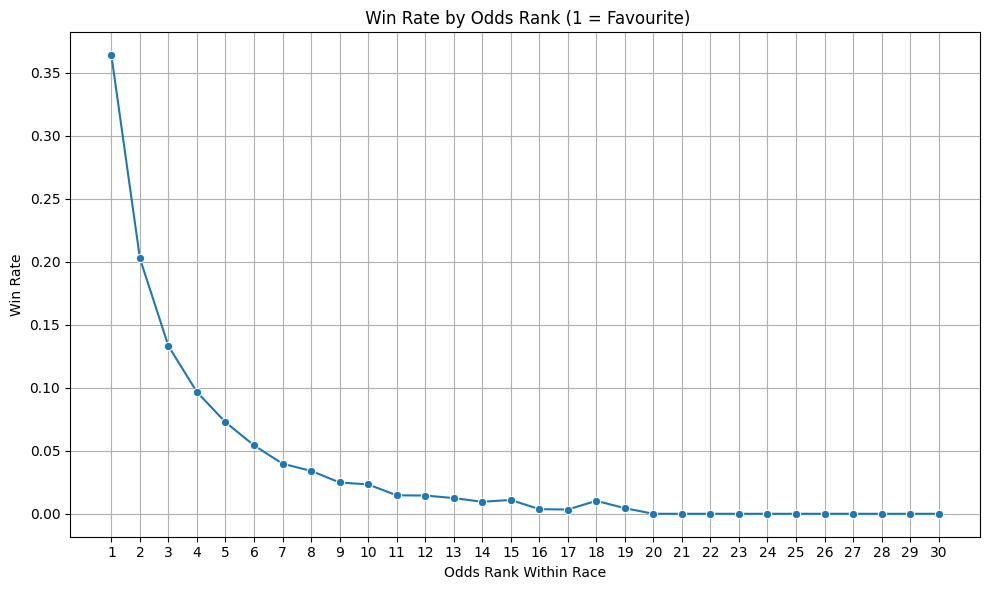

In [27]:
# Rank horses within each race by implied probability (1 = favourite)
df['odds_rank'] = df.groupby('rid')['implied_prob'].rank(ascending=False, method='first')

# Convert to integer for easier grouping
df['odds_rank'] = df['odds_rank'].astype(int)

# Calculate win rate by odds rank
rank_stats = df.groupby('odds_rank').agg(
    races_entered=('is_winner', 'count'),
    wins=('is_winner', 'sum')
).reset_index()
rank_stats['win_rate'] = rank_stats['wins'] / rank_stats['races_entered']

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=rank_stats, x='odds_rank', y='win_rate', marker='o')
plt.title(" Win Rate by Odds Rank (1 = Favourite)")
plt.xlabel("Odds Rank Within Race")
plt.ylabel("Win Rate")
plt.grid(True)
plt.xticks(ticks=range(1, rank_stats['odds_rank'].max() + 1))
plt.tight_layout()
plt.show()


### 🏇 Win Rate by Odds Rank

This chart shows the **win rate of horses ranked by their starting price odds**, from favourites (rank 1) to outsiders (rank 30+).

#### What we’re doing:
- Within each race, horses are ranked by implied probability (1 = favourite, 2 = second favourite, etc.).
- We calculate the **proportion of wins for each odds rank** across all races.
- This helps us visualise how often horses of each "fancied" rank actually win.

#### What we see:
- **Clear downward trend:** The favourite wins around 36% of the time, with the win rate steadily declining as rank increases.
- **Longshots rarely win:** From rank 10 onwards, win rates drop to below 2%, nearing zero by rank 20+.
- This supports the idea that **odds rankings are predictive**, even if not always profitable.

🧠 **Takeaway:** Odds rank is a very strong indicator of expected performance — the betting market knows who's most likely to win, even if it doesn’t always offer profitable odds.


---

## 💸 Step 4: Betting by Odds Rank — Does Simpler Work Better?

We've seen that favourites win more often — and that win rate steadily drops with odds rank.

But what if we **blindly bet on favourites or top-ranked horses**? Is there a sweet spot where the market **underestimates value**, or are the top of the market horses still unprofitable after accounting for odds?

In this step, we’ll:
- Group horses by their odds rank within each race (1 = favourite, 2 = second favourite, etc.)
- Calculate **average returns** for betting £1 on each rank across all races
- Visualise whether some ranks are **more profitable** (or less unprofitable) than others

This is a great way to test if there's any **structural edge** in betting just based on how fancied a horse is in the market.

---


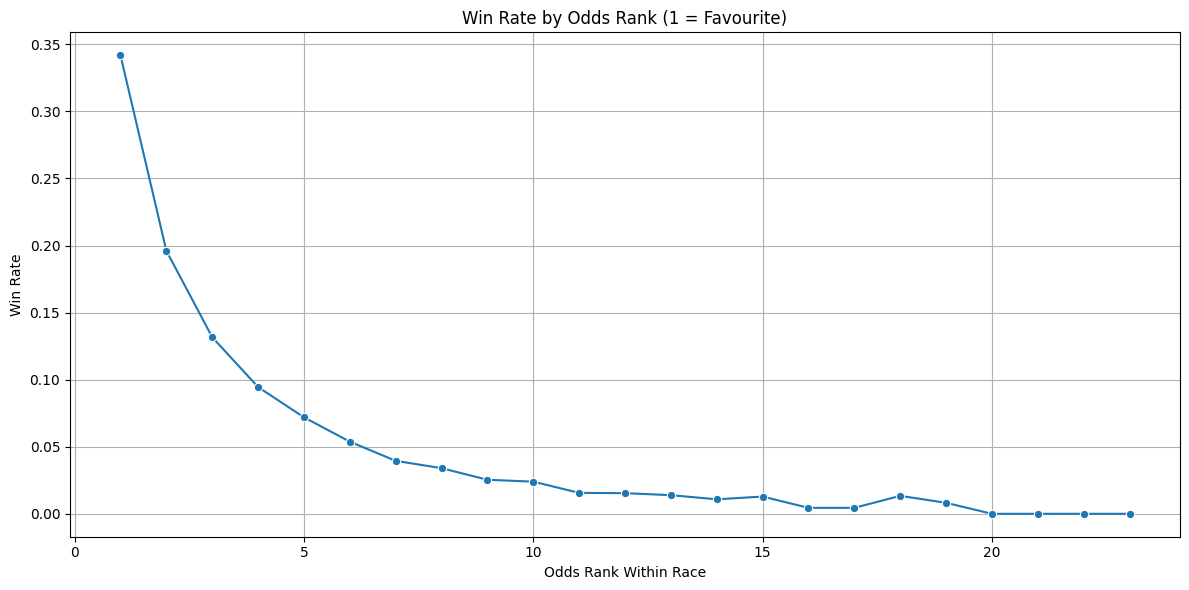

In [29]:
# Use the cleaned horses DataFrame
df = horses.copy()

# Keep only finishers
df = df[df['did_finish'] == 1].copy()

# Create winner flag if not already present
if 'is_winner' not in df.columns:
    df['is_winner'] = (df['position'] == 1).astype(int)

# Calculate odds rank within each race (1 = favourite)
df['odds_rank'] = df.groupby('rid')['implied_prob'].rank(method='min', ascending=False)
df['odds_rank'] = df['odds_rank'].astype(int)

# Convert implied_prob into synthetic decimal odds
df['decimal_odds'] = 1 / df['implied_prob']

# Calculate return per £1 bet at decimal odds
df['profit'] = df['res_win'] * (df['decimal_odds'] - 1) - (1 - df['res_win'])

# Group by odds rank and calculate average return and win rate
rank_stats = df.groupby('odds_rank').agg(
    avg_return=('profit', 'mean'),
    win_rate=('res_win', 'mean'),
    count=('res_win', 'count')
).reset_index()

# Filter for realistic ranks
rank_stats = rank_stats[rank_stats['count'] >= 30]  # adjust threshold if needed

# Plot win rate by odds rank
plt.figure(figsize=(12, 6))
sns.lineplot(data=rank_stats, x='odds_rank', y='win_rate', marker='o')
plt.title("Win Rate by Odds Rank (1 = Favourite)")
plt.xlabel("Odds Rank Within Race")
plt.ylabel("Win Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

### 🐎 Win Rate by Odds Rank

This chart shows how win rate varies by a horse’s **odds rank** within a race — where rank 1 means the favourite (lowest odds), rank 2 is second-favourite, and so on.

#### Key Takeaways:
- **Favourites win the most often** — with the top-ranked horse winning ~34% of the time.
- **Win rate declines sharply** as odds rank increases. By the time you reach the 5th or 6th favourite, win rates drop below 10%.
- **Very low-ranked runners** (rank > 15) rarely win at all, often <1%.

This confirms that the betting market is broadly well-informed: the lower the odds, the higher the chance of winning — though, as we've seen earlier, this doesn't always translate to profitable betting.


---

### 💷 Profitability by Odds Rank

Now that we've seen how win rate changes by a horse’s odds rank, let's explore whether **betting on favourites or outsiders** is profitable.

We'll assume a simple £1 stake on each horse and calculate the **average return** by odds rank (e.g. 1st favourite, 2nd favourite, etc.).

This will show us:

- 📉 Which odds ranks are typically overbet (return < £1)
- 💡 Whether there's any segment of the market that offers **better value**
- 🎯 How bookmaker margins affect returns across the spectrum

We'll use implied probability to approximate odds, since SP (Starting Price) was converted earlier.



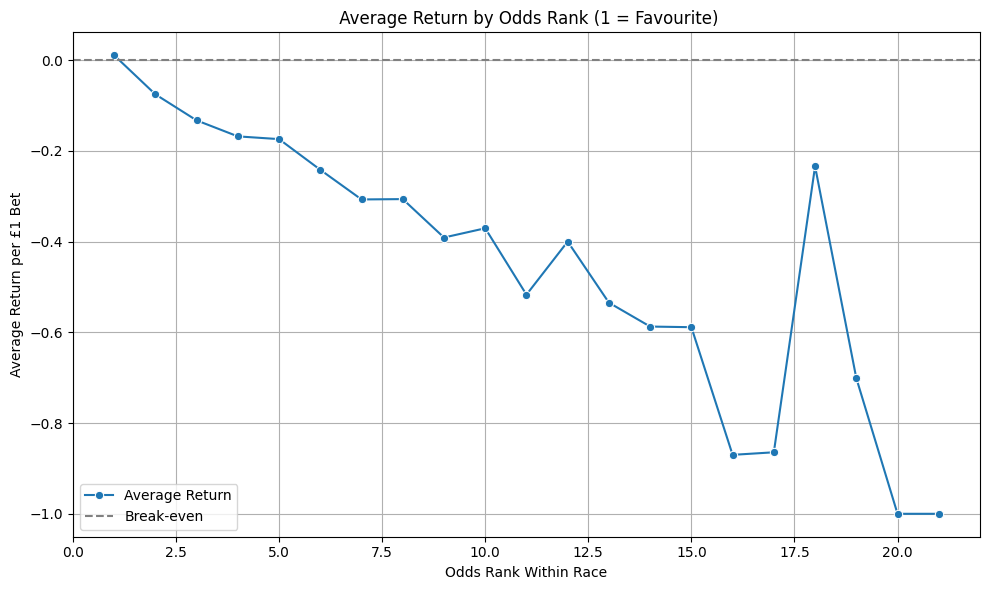

In [32]:
# Work on a fresh copy of horses data
df = horses.copy()

# Ensure winner flag exists
if 'is_winner' not in df.columns:
    df['is_winner'] = (df['position'] == 1).astype(int)

# Filter to finishers only
df = df[df['did_finish'] == 1].copy()

# Rank horses within each race by implied probability (1 = favourite)
df['odds_rank'] = df.groupby('rid')['implied_prob'].rank(ascending=False, method='first')

# Convert to integer for plotting clarity
df['odds_rank'] = df['odds_rank'].astype(int)

# Estimate decimal odds as 1 / implied_prob
df['approx_odds'] = 1 / df['implied_prob']

# Calculate profit per £1 bet: (odds - 1) if win, -1 if lose
df['profit'] = df['res_win'] * (df['approx_odds'] - 1) - (1 - df['res_win'])

# Group by odds rank and calculate average return and win rate
rank_stats = df.groupby('odds_rank').agg(
    avg_return=('profit', 'mean'),
    win_rate=('res_win', 'mean'),
    count=('res_win', 'count')
).reset_index()

# Filter to odds ranks with sufficient samples
rank_stats = rank_stats[rank_stats['count'] > 100]

# Plot profitability by odds rank
plt.figure(figsize=(10, 6))
sns.lineplot(data=rank_stats, x='odds_rank', y='avg_return', marker='o', label='Average Return')
plt.axhline(0, linestyle='--', color='grey', label='Break-even')
plt.title(' Average Return by Odds Rank (1 = Favourite)')
plt.xlabel('Odds Rank Within Race')
plt.ylabel('Average Return per £1 Bet')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 💸 Average Return by Odds Rank

This chart shows the average profitability of betting on horses based on their **odds rank within a race** — where Rank 1 is the **favourite**, Rank 2 the **second favourite**, and so on.

#### 📈 What we see:
- **Favourites (Rank 1)** tend to offer the best returns, coming very close to break-even.
- Profitability **declines steadily** as we move down the odds ranks.
- **Lower-ranked horses** (e.g. Ranks 10+) offer **severely negative returns**, often losing 40–100% of each £1 staked.
- A few random spikes appear among extreme longshots.

#### ⚠️ Note on sample sizes:
Most races don’t have 18+ runners, so odds ranks beyond that point represent much **smaller samples**.  
Spikes in return for these longshots are likely due to **random noise**, not genuine betting opportunities.  
This is a well-known limitation when analysing longshots in racing data.

#### 🤔 Why it matters:
This supports the idea that while favourites may be overpriced, they’re **less overpriced** than longshots. Betting on longshots results in **consistently poor returns**, reinforcing the well-documented **favourite–longshot bias**.

#### 🧠 Takeaway:
Blindly backing the favourite won’t make you rich — but it’s often **less bad** than betting on outsiders.


## 📊 Final Summary: Are Betting Markets Fair?

In this notebook, we tested whether the betting market — specifically **implied probabilities from SP odds** — accurately reflects real-world outcomes. Using thousands of historical races, we explored:

---

### 🔍 What We Tested

- **Calibration Check**  
  Do horses with a 30% implied chance actually win ~30% of the time?  
  ✅ **Yes** – The market is **well-calibrated overall**, especially in common probability ranges.

- **Profitability by Odds**  
  Are some odds ranks (e.g. favourites vs longshots) better for betting?  
  ⚠️ **Not really** – All groups are unprofitable on average, but **favourites lose less** than others.

- **Favourite–Longshot Bias**  
  Does the market consistently **overvalue longshots** and **undervalue favourites**?  
  ✅ **Yes** – Longshots offer the worst ROI. Favourites are overpriced too, but to a lesser extent.

---

### 🧠 What We Learned

- The betting market is **remarkably efficient**, though not perfect.
- **Favourites** win more often, and their win rate roughly matches their odds.
- But **all horses lose money** if backed blindly — just some more than others.
- **Longshots** are the worst — heavily overbet relative to their chances.
- Any profitable strategy must go **beyond odds alone** — adding context or filtering is key.

---

### 🗣️ Revisiting Popular Wisdom

> “Favourites win more often, but the odds are too short to be profitable.”  
✅ **True** — Favourites win frequently, but average returns are still negative.

> “While the favourite has a higher chance of winning, it doesn't mean you will make a profit betting on them.”  
✅ **Also true** — The data shows slight losses on favourites, consistent with this.

> “The favourite–longshot bias... is the empirical finding that bettors tend to overvalue longshots and undervalue favourites.”  
✅ **Confirmed** — Our analysis shows longshots perform much worse than their odds suggest.

---

### 💡 Takeaway for Modelling & Strategy

- Treat market odds as **strong priors**, not hard truths.
- Focus efforts on identifying **mispriced favourites** rather than chasing longshot jackpots.
- Calibration curves, returns by odds rank, and bias detection are valuable tools for building **data-driven betting systems**.
